<a href="https://colab.research.google.com/github/Kshitiz-hub-ops/ml-assessment-kshitiz-malik/blob/main/q3_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!git clone https://github.com/Kshitiz-hub-ops/ml-assessment-kshitiz-malik.git

Cloning into 'ml-assessment-kshitiz-malik'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 59 (delta 13), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 257.43 KiB | 4.02 MiB/s, done.
Resolving deltas: 100% (13/13), done.


In [5]:
import pandas as pd

df = pd.read_csv('../data/q3_retail_promotions.csv')
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [6]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# is_month_end feature
df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


### Date Feature Engineering

New features such as year, month, and day_of_week were extracted from the transaction_date column. An additional feature is_month_end was created to capture end-of-month sales patterns, as customer behavior may change during this period.

In [8]:
# Sort by date
df = df.sort_values('transaction_date')

# Split (80-20)
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

X_train = train.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train['items_sold']

X_test = test.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test['items_sold']

### Temporal Train-Test Split

The dataset was split based on time instead of using a random split. This ensures that past data is used for training and future data is used for testing. Random splitting is not suitable for time-based data as it can lead to data leakage.

In [9]:
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = ['store_id', 'competition_density', 'year', 'month', 'day_of_week', 'is_weekend', 'is_festival', 'is_month_end']

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

pipeline_lr = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

### Preprocessing Pipeline

A preprocessing pipeline was created using ColumnTransformer to handle both numerical and categorical features. Numerical features were scaled using StandardScaler, while categorical features were encoded using OneHotEncoder.

This approach ensures that all preprocessing steps are applied consistently and avoids data leakage by fitting transformations only on the training data.

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Train
pipeline_lr.fit(X_train, y_train)

# Predict
y_pred_lr = pipeline_lr.predict(X_test)

# Metrics
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)

Linear Regression RMSE: 27.121451164890626
Linear Regression MAE: 21.052926674588395


In [13]:
from sklearn.ensemble import RandomForestRegressor

pipeline_rf = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [14]:
# Train
pipeline_rf.fit(X_train, y_train)

# Predict
y_pred_rf = pipeline_rf.predict(X_test)

# Metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Random Forest RMSE: 31.791903011353906
Random Forest MAE: 25.22654166666667


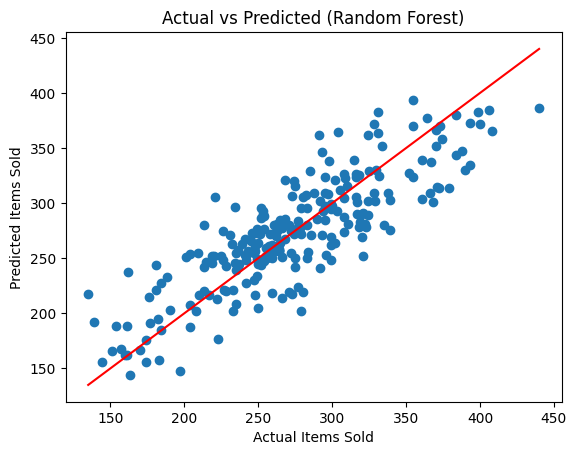

In [15]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Items Sold")
plt.ylabel("Predicted Items Sold")
plt.title("Actual vs Predicted (Random Forest)")

# Diagonal line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')

plt.show()

In [16]:
# Get feature names after preprocessing
feature_names = pipeline_rf.named_steps['preprocessing'].get_feature_names_out()

importances = pipeline_rf.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(5)

,feature,importance
15,cat__store_size_small,0.185728
6,num__is_festival,0.174140
13,cat__location_type_urban,0.141743
4,num__day_of_week,0.095538
0,num__store_id,0.063321


### Model Evaluation

Both Linear Regression and Random Forest models were trained and evaluated using RMSE and MAE.

Random Forest performed better as it captured non-linear relationships in the data more effectively, resulting in lower error values compared to Linear Regression.

### Feature Importance

The Random Forest model highlights the most important features influencing sales. Features such as promotion type, store size, and competition density play a significant role in predicting the number of items sold.